In [1]:
from sklearn.datasets import load_breast_cancer
import pandas as pd

data = load_breast_cancer()

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [2]:
print(type(data))
print(data.keys())

<class 'sklearn.utils._bunch.Bunch'>
dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])


In [3]:
df = pd.DataFrame(
    data.data,
    columns=data.feature_names
)

df["target"] = data.target

print(df.shape)
print(df.head())

(569, 31)
   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430         0.1809   

   mean fractal dimension  ...  worst texture  worst perimeter  worst area  \
0   

In [4]:
print("Target names:", data.target_names)
print(df["target"].value_counts())

Target names: ['malignant' 'benign']
target
1    357
0    212
Name: count, dtype: int64


In [5]:
df.to_csv("../data/raw/breast_cancer.csv", index=False)

print("Dataset saved successfully!")

Dataset saved successfully!


In [6]:
print("Data types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum().sum())

print("\nDuplicated rows:")
print(df.duplicated().sum())

Data types:
mean radius                float64
mean texture               float64
mean perimeter             float64
mean area                  float64
mean smoothness            float64
mean compactness           float64
mean concavity             float64
mean concave points        float64
mean symmetry              float64
mean fractal dimension     float64
radius error               float64
texture error              float64
perimeter error            float64
area error                 float64
smoothness error           float64
compactness error          float64
concavity error            float64
concave points error       float64
symmetry error             float64
fractal dimension error    float64
worst radius               float64
worst texture              float64
worst perimeter            float64
worst area                 float64
worst smoothness           float64
worst compactness          float64
worst concavity            float64
worst concave points       float64
worst sy

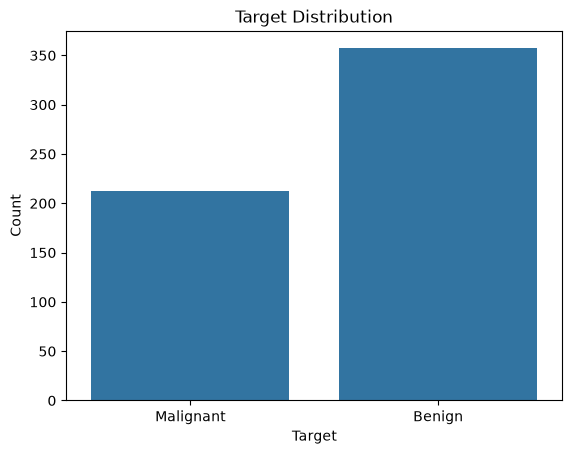

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(x="target", data=df)

plt.title("Target Distribution")
plt.xlabel("Target")
plt.ylabel("Count")
plt.xticks([0, 1], ["Malignant", "Benign"])

plt.show()

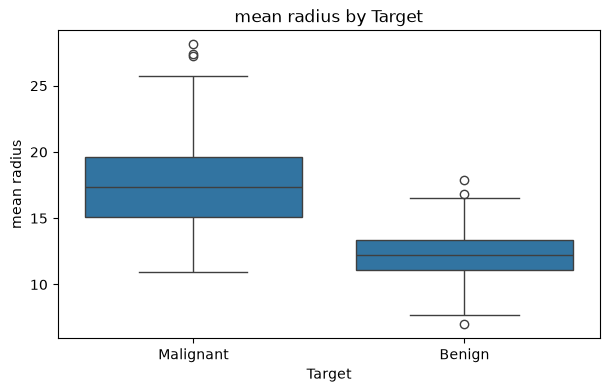

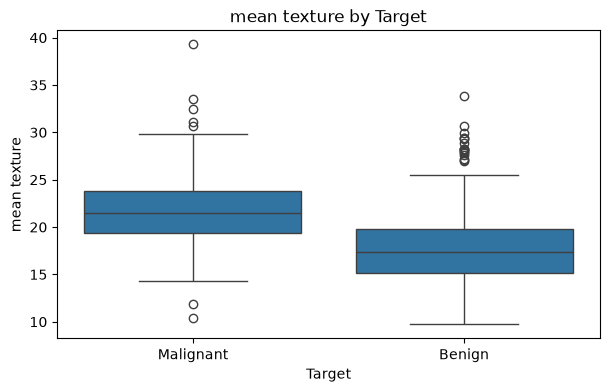

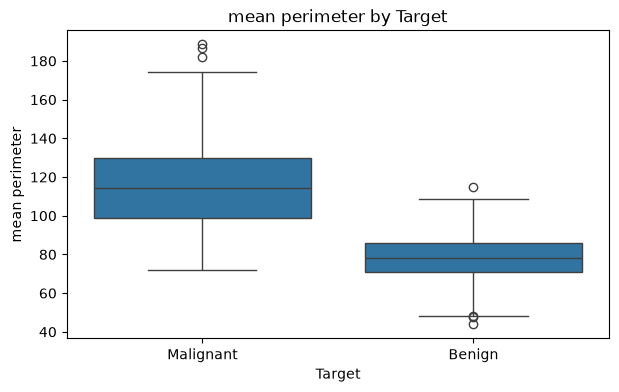

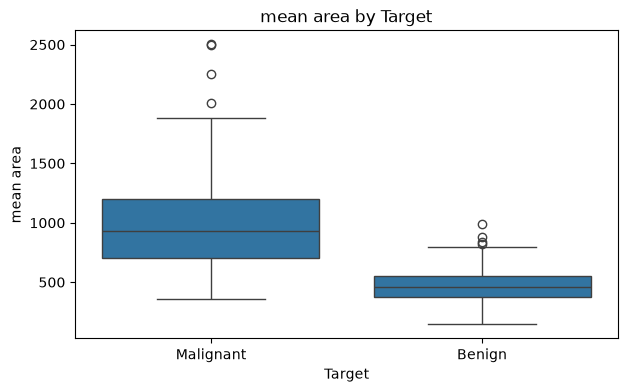

In [8]:
features_to_plot = [
    "mean radius",
    "mean texture",
    "mean perimeter",
    "mean area"
]

for feature in features_to_plot:
    plt.figure(figsize=(7, 4))
    
    sns.boxplot(
        x="target",
        y=feature,
        data=df
    )
    
    plt.title(f"{feature} by Target")
    plt.xlabel("Target")
    plt.ylabel(feature)
    plt.xticks([0, 1], ["Malignant", "Benign"])
    
    plt.show()

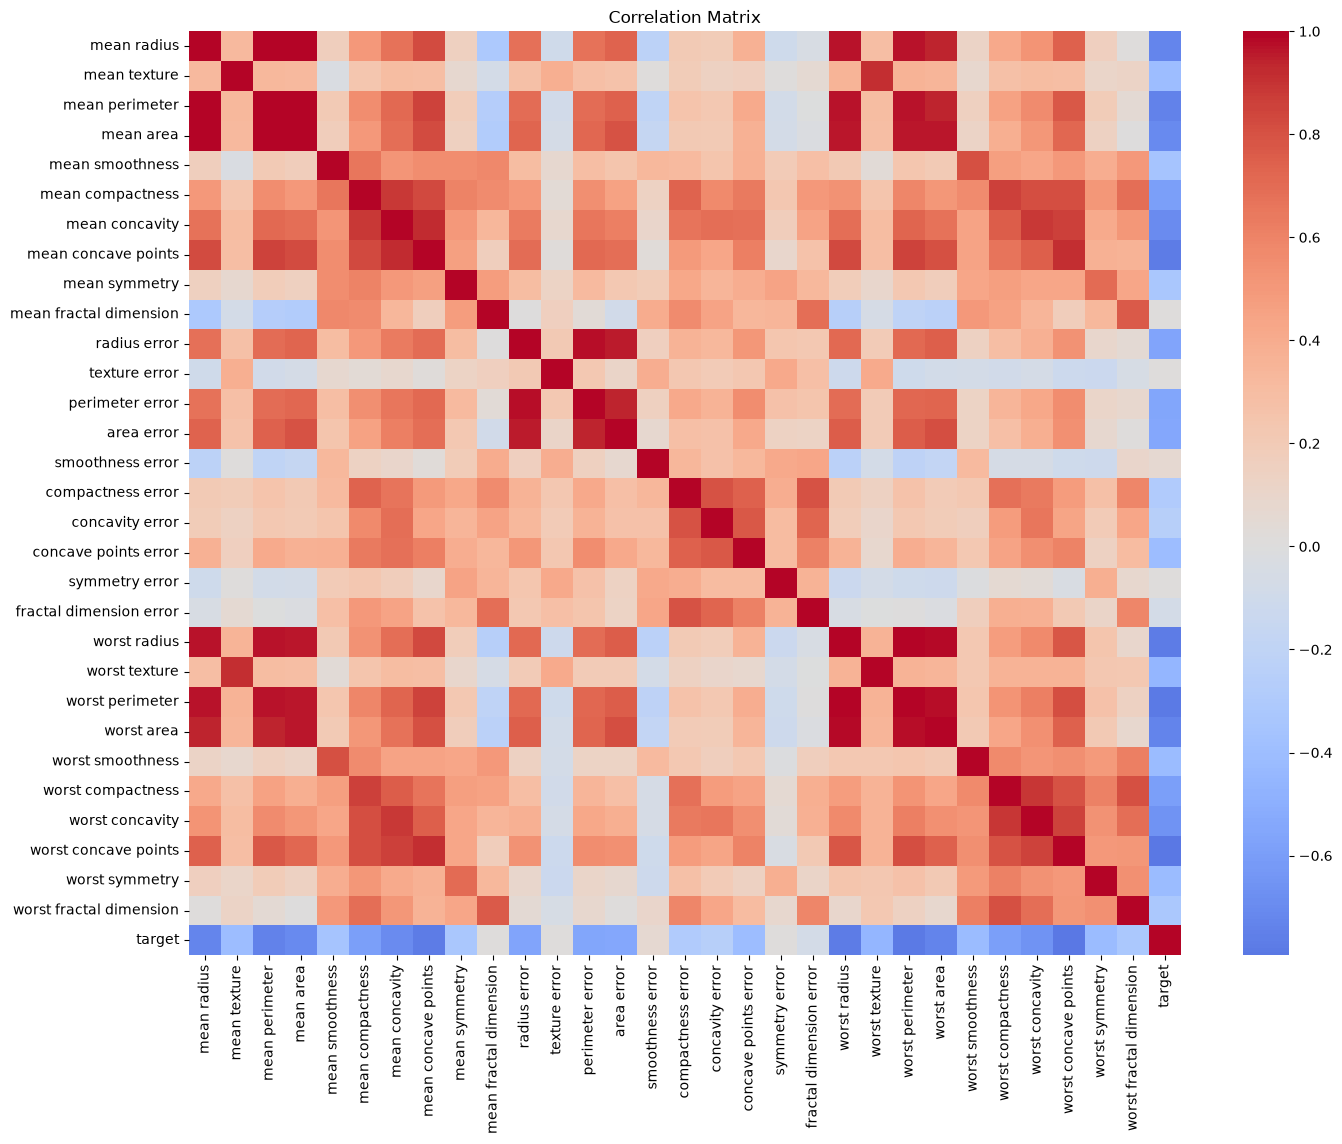

In [9]:
correlation = df.corr(numeric_only=True)

plt.figure(figsize=(16, 12))

sns.heatmap(
    correlation,
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix")
plt.show()

In [10]:
target_correlation = (
    df.corr(numeric_only=True)["target"]
    .drop("target")
    .sort_values()
)

print(target_correlation)

worst concave points      -0.793566
worst perimeter           -0.782914
mean concave points       -0.776614
worst radius              -0.776454
mean perimeter            -0.742636
worst area                -0.733825
mean radius               -0.730029
mean area                 -0.708984
mean concavity            -0.696360
worst concavity           -0.659610
mean compactness          -0.596534
worst compactness         -0.590998
radius error              -0.567134
perimeter error           -0.556141
area error                -0.548236
worst texture             -0.456903
worst smoothness          -0.421465
worst symmetry            -0.416294
mean texture              -0.415185
concave points error      -0.408042
mean smoothness           -0.358560
mean symmetry             -0.330499
worst fractal dimension   -0.323872
compactness error         -0.292999
concavity error           -0.253730
fractal dimension error   -0.077972
symmetry error             0.006522
texture error              0

In [11]:
from sklearn.model_selection import train_test_split

X = df.drop("target", axis=1)
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (455, 30)
X_test: (114, 30)
y_train: (455,)
y_test: (114,)


In [12]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

linear_svm_pipeline = Pipeline(
    steps=[
        ("scaler", StandardScaler()),
        ("svm", SVC(kernel="linear"))
    ]
)

linear_svm_pipeline.fit(X_train, y_train)

y_pred = linear_svm_pipeline.predict(X_test)

print("Predictions generated successfully!")

Predictions generated successfully!


In [13]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

y_score = linear_svm_pipeline.decision_function(X_test)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_score)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-Score : {f1:.4f}")
print(f"ROC-AUC  : {roc_auc:.4f}")

Accuracy : 0.9737
Precision: 0.9859
Recall   : 0.9722
F1-Score : 0.9790
ROC-AUC  : 0.9964


In [14]:
print(confusion_matrix(y_test, y_pred))

[[41  1]
 [ 2 70]]


In [15]:
rbf_svm_pipeline = Pipeline(
    steps=[
        ("scaler", StandardScaler()),
        ("svm", SVC(kernel="rbf"))
    ]
)

rbf_svm_pipeline.fit(X_train, y_train)

y_pred_rbf = rbf_svm_pipeline.predict(X_test)

y_score_rbf = rbf_svm_pipeline.decision_function(X_test)

print("RBF SVM trained successfully!")

RBF SVM trained successfully!


In [16]:
accuracy_rbf = accuracy_score(y_test, y_pred_rbf)
precision_rbf = precision_score(y_test, y_pred_rbf)
recall_rbf = recall_score(y_test, y_pred_rbf)
f1_rbf = f1_score(y_test, y_pred_rbf)
roc_auc_rbf = roc_auc_score(y_test, y_score_rbf)

print(f"Accuracy : {accuracy_rbf:.4f}")
print(f"Precision: {precision_rbf:.4f}")
print(f"Recall   : {recall_rbf:.4f}")
print(f"F1-Score : {f1_rbf:.4f}")
print(f"ROC-AUC  : {roc_auc_rbf:.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_rbf))

Accuracy : 0.9825
Precision: 0.9861
Recall   : 0.9861
F1-Score : 0.9861
ROC-AUC  : 0.9950

Confusion Matrix:
[[41  1]
 [ 1 71]]


In [18]:
C_values = [0.01, 0.1, 1, 100]

for c in C_values:
    svm_pipeline = Pipeline(
        steps=[
            ("scaler", StandardScaler()),
            ("svm", SVC(
                kernel="rbf",
                C=c
            ))
        ]
    )
    
    svm_pipeline.fit(X_train, y_train)
    
    predictions = svm_pipeline.predict(X_test)
    scores = svm_pipeline.decision_function(X_test)
    
    print(f"\nC = {c}")
    print(f"Accuracy : {accuracy_score(y_test, predictions):.4f}")
    print(f"Precision: {precision_score(y_test, predictions):.4f}")
    print(f"Recall   : {recall_score(y_test, predictions):.4f}")
    print(f"F1-Score : {f1_score(y_test, predictions):.4f}")
    print(f"ROC-AUC  : {roc_auc_score(y_test, scores):.4f}")


C = 0.01
Accuracy : 0.6316
Precision: 0.6316
Recall   : 1.0000
F1-Score : 0.7742
ROC-AUC  : 0.9854

C = 0.1
Accuracy : 0.9474
Precision: 0.9459
Recall   : 0.9722
F1-Score : 0.9589
ROC-AUC  : 0.9901

C = 1
Accuracy : 0.9825
Precision: 0.9861
Recall   : 0.9861
F1-Score : 0.9861
ROC-AUC  : 0.9950

C = 100
Accuracy : 0.9474
Precision: 0.9853
Recall   : 0.9306
F1-Score : 0.9571
ROC-AUC  : 0.9888


In [19]:
gamma_values = [0.001, 0.01, 0.1, 1, 10]

for gamma in gamma_values:
    svm_pipeline = Pipeline(
        steps=[
            ("scaler", StandardScaler()),
            ("svm", SVC(
                kernel="rbf",
                C=1,
                gamma=gamma
            ))
        ]
    )
    
    svm_pipeline.fit(X_train, y_train)
    
    predictions = svm_pipeline.predict(X_test)
    scores = svm_pipeline.decision_function(X_test)
    
    print(f"\nGamma = {gamma}")
    print(f"Accuracy : {accuracy_score(y_test, predictions):.4f}")
    print(f"Precision: {precision_score(y_test, predictions):.4f}")
    print(f"Recall   : {recall_score(y_test, predictions):.4f}")
    print(f"F1-Score : {f1_score(y_test, predictions):.4f}")
    print(f"ROC-AUC  : {roc_auc_score(y_test, scores):.4f}")


Gamma = 0.001
Accuracy : 0.9561
Precision: 0.9351
Recall   : 1.0000
F1-Score : 0.9664
ROC-AUC  : 0.9940

Gamma = 0.01
Accuracy : 0.9825
Precision: 0.9861
Recall   : 0.9861
F1-Score : 0.9861
ROC-AUC  : 0.9957

Gamma = 0.1
Accuracy : 0.9561
Precision: 0.9855
Recall   : 0.9444
F1-Score : 0.9645
ROC-AUC  : 0.9937

Gamma = 1
Accuracy : 0.6316
Precision: 0.6316
Recall   : 1.0000
F1-Score : 0.7742
ROC-AUC  : 0.9481

Gamma = 10
Accuracy : 0.6316
Precision: 0.6316
Recall   : 1.0000
F1-Score : 0.7742
ROC-AUC  : 0.7607


In [20]:
gamma = 10

svm_pipeline = Pipeline(
    steps=[
        ("scaler", StandardScaler()),
        ("svm", SVC(
            kernel="rbf",
            C=1,
            gamma=gamma
        ))
    ]
)

svm_pipeline.fit(X_train, y_train)

predictions = svm_pipeline.predict(X_test)
scores = svm_pipeline.decision_function(X_test)

print(f"Gamma = {gamma}")
print(f"Accuracy : {accuracy_score(y_test, predictions):.4f}")
print(f"Precision: {precision_score(y_test, predictions):.4f}")
print(f"Recall   : {recall_score(y_test, predictions):.4f}")
print(f"F1-Score : {f1_score(y_test, predictions):.4f}")
print(f"ROC-AUC  : {roc_auc_score(y_test, scores):.4f}")

Gamma = 10
Accuracy : 0.6316
Precision: 0.6316
Recall   : 1.0000
F1-Score : 0.7742
ROC-AUC  : 0.7607


In [21]:
kernel_configs = {
    "Linear": {
        "kernel": "linear",
        "C": 1
    },
    "RBF": {
        "kernel": "rbf",
        "C": 1,
        "gamma": 0.01
    },
    "Polynomial": {
        "kernel": "poly",
        "C": 1,
        "degree": 3
    }
}

kernel_results = []

for name, params in kernel_configs.items():
    
    svm_pipeline = Pipeline(
        steps=[
            ("scaler", StandardScaler()),
            ("svm", SVC(**params))
        ]
    )
    
    svm_pipeline.fit(X_train, y_train)
    
    predictions = svm_pipeline.predict(X_test)
    scores = svm_pipeline.decision_function(X_test)
    
    kernel_results.append({
        "Kernel": name,
        "Accuracy": accuracy_score(y_test, predictions),
        "Precision": precision_score(y_test, predictions),
        "Recall": recall_score(y_test, predictions),
        "F1": f1_score(y_test, predictions),
        "ROC-AUC": roc_auc_score(y_test, scores)
    })

kernel_results_df = pd.DataFrame(kernel_results)

print(kernel_results_df)

       Kernel  Accuracy  Precision    Recall        F1   ROC-AUC
0      Linear  0.973684   0.985915  0.972222  0.979021  0.996362
1         RBF  0.982456   0.986111  0.986111  0.986111  0.995701
2  Polynomial  0.912281   0.878049  1.000000  0.935065  0.995370


In [22]:
from sklearn.model_selection import GridSearchCV

svm_pipeline = Pipeline(
    steps=[
        ("scaler", StandardScaler()),
        ("svm", SVC())
    ]
)

param_grid = [
    {
        "svm__kernel": ["linear"],
        "svm__C": [0.01, 0.1, 1, 10, 100]
    },
    {
        "svm__kernel": ["rbf"],
        "svm__C": [0.01, 0.1, 1, 10, 100],
        "svm__gamma": [0.001, 0.01, 0.1, 1]
    },
    {
        "svm__kernel": ["poly"],
        "svm__C": [0.1, 1, 10],
        "svm__degree": [2, 3, 4],
        "svm__gamma": ["scale", 0.01, 0.1]
    }
]

grid_search = GridSearchCV(
    estimator=svm_pipeline,
    param_grid=param_grid,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest CV ROC-AUC:")
print(grid_search.best_score_)

Best Parameters:
{'svm__C': 10, 'svm__gamma': 0.01, 'svm__kernel': 'rbf'}

Best CV ROC-AUC:
0.9953560371517028


In [23]:
final_model = grid_search.best_estimator_

y_pred_final = final_model.predict(X_test)
y_score_final = final_model.decision_function(X_test)

print("Final Model Parameters:")
print(grid_search.best_params_)

print("\nFinal Test Performance:")
print(f"Accuracy : {accuracy_score(y_test, y_pred_final):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_final):.4f}")
print(f"Recall   : {recall_score(y_test, y_pred_final):.4f}")
print(f"F1-Score : {f1_score(y_test, y_pred_final):.4f}")
print(f"ROC-AUC  : {roc_auc_score(y_test, y_score_final):.4f}")

Final Model Parameters:
{'svm__C': 10, 'svm__gamma': 0.01, 'svm__kernel': 'rbf'}

Final Test Performance:
Accuracy : 0.9825
Precision: 0.9861
Recall   : 0.9861
F1-Score : 0.9861
ROC-AUC  : 0.9977


In [24]:
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_final))

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred_final,
        target_names=["Malignant", "Benign"]
    )
)

Confusion Matrix:
[[41  1]
 [ 1 71]]

Classification Report:
              precision    recall  f1-score   support

   Malignant       0.98      0.98      0.98        42
      Benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



In [25]:
error_mask = y_test != y_pred_final

errors = X_test[error_mask].copy()
errors["Actual"] = y_test[error_mask]
errors["Predicted"] = y_pred_final[error_mask]
errors["Decision_Score"] = y_score_final[error_mask]

print("Number of errors:", len(errors))
print(errors)

Number of errors: 2
     mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
541        14.47         24.99           95.81      656.4          0.08837   
73         13.80         15.79           90.43      584.1          0.10070   

     mean compactness  mean concavity  mean concave points  mean symmetry  \
541             0.123         0.10090              0.03890         0.1872   
73              0.128         0.07789              0.05069         0.1662   

     mean fractal dimension  ...  worst area  worst smoothness  \
541                 0.06341  ...       808.9            0.1340   
73                  0.06566  ...       812.4            0.1411   

     worst compactness  worst concavity  worst concave points  worst symmetry  \
541             0.4202           0.4040                0.1205          0.3187   
73              0.3542           0.2779                0.1383          0.2589   

     worst fractal dimension  Actual  Predicted  Decision_Score  
541 

In [26]:
import joblib

final_model = grid_search.best_estimator_

model_path = "../models/breast_cancer_svm_pipeline.pkl"

joblib.dump(final_model, model_path)

print("Model saved successfully!")
print("Path:", model_path)

Model saved successfully!
Path: ../models/breast_cancer_svm_pipeline.pkl


In [27]:
import joblib

final_model = grid_search.best_estimator_

model_path = "../models/breast_cancer_svm_pipeline.pkl"

joblib.dump(final_model, model_path)

print("Model saved successfully!")
print("Path:", model_path)

Model saved successfully!
Path: ../models/breast_cancer_svm_pipeline.pkl


In [28]:
loaded_model = joblib.load(model_path)

print("Model loaded successfully!")
print(loaded_model)

Model loaded successfully!
Pipeline(steps=[('scaler', StandardScaler()), ('svm', SVC(C=10, gamma=0.01))])


In [29]:
loaded_predictions = loaded_model.predict(X_test)

print("Predictions match:",
      (loaded_predictions == y_pred_final).all())

Predictions match: True
